<a href="https://colab.research.google.com/github/mamaboss04/week7_lab/blob/main/CNN_Image_Classfication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Convolutional Neural Networks (CNNs)
## Image Classification, Hyperparameter Tuning & Regularization with PyTorch


---

## Table of Contents

1. [Introduction & Learning Objectives](#introduction)
2. [Prerequisites & Imports](#imports)
3. [Part 1: Quick Tutorial – CNN on MNIST](#part1)
   - [3.1 Load and Visualize MNIST](#31)
   - [3.2 Define a Simple CNN](#32)
   - [3.3 Training Setup](#33)
   - [3.4 Training Loop + Live Plot](#34)
   - [3.5 Evaluation & Confusion Matrix](#35)
   - [3.6 Quick Hyperparameter Experiment](#36)
4. [Part 2: Student Tasks & grading](#part2)
5. [Lab Summary & Takeaways](#summary)
6. [References & Further Reading](#refs)

---

<a id="introduction"></a>
## Introduction

Convolutional Neural Networks (**CNNs**) learn **spatial hierarchies of features** from images using **convolution**, **nonlinearities**, and **pooling**. They are the standard backbone for image understanding and underpin many **generative** systems (e.g., encoders in **VAEs**, discriminators in **GANs**, and **U-Net**-style architectures in **diffusion** models).

### Learning Objectives

By the end of this lab, you will be able to:

- **Load** image data with `torchvision` and **batch** it with `DataLoader`.
- **Implement** a small CNN in **PyTorch** (`nn.Module`, conv/pool/FC layers).
- **Train** a classifier with a standard **loss**, **optimizer**, and **GPU/CPU** device placement.
- **Interpret** training curves and a **confusion matrix**.
- **Experiment** with **hyperparameters**, **dropout**, **weight decay**, and **data augmentation**.

### How to use this notebook

- Run cells **top to bottom** the first time.
- Short explanations appear **before** major code cells; read them before running.
- **Part 2** is graded / self-checked—complete tasks in order when instructed.


<a id="imports"></a>
## Prerequisites & Imports

You need **Python 3** with **PyTorch**, **torchvision**, and plotting libraries. This cell prints versions for reproducibility and selects **CPU or CUDA**.


In [1]:
# Standard library & numerics
import os
import random
import numpy as np

# PyTorch ecosystem
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T

# torchaudio is part of the PyTorch ecosystem (audio CNNs / spectrograms in other labs)
import torchaudio  # noqa: F401 — ensures install; not required for MNIST images

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Jupyter / training utilities
from IPython.display import clear_output
from sklearn.metrics import confusion_matrix

# Reproducibility (best-effort across CPU/GPU)
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"torchvision version: {torchvision.__version__}")
print(f"torchaudio version: {torchaudio.__version__}")
print(f"Device: {device}")
if device.type == "cuda":
    print(torch.cuda.get_device_name(0))


PyTorch version: 2.10.0+cu128
torchvision version: 0.25.0+cu128
torchaudio version: 2.10.0+cu128
Device: cuda
Tesla T4


<a id="part1"></a>
## Part 1: Quick Tutorial – Training a CNN on MNIST (≈40–45 minutes)

**MNIST** is 28×28 grayscale digits (10 classes). It trains quickly—ideal for learning CNN mechanics before scaling to harder datasets or generative models.


<a id="31"></a>
### 3.1 Load and Visualize MNIST (≈8 min)

We use **`transforms`** to convert images to tensors and **normalize** pixel values. **`DataLoader`** shuffles training batches and can use multiple workers for faster loading.


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.05MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.5MB/s]


Train samples: 60000 | Test samples: 10000


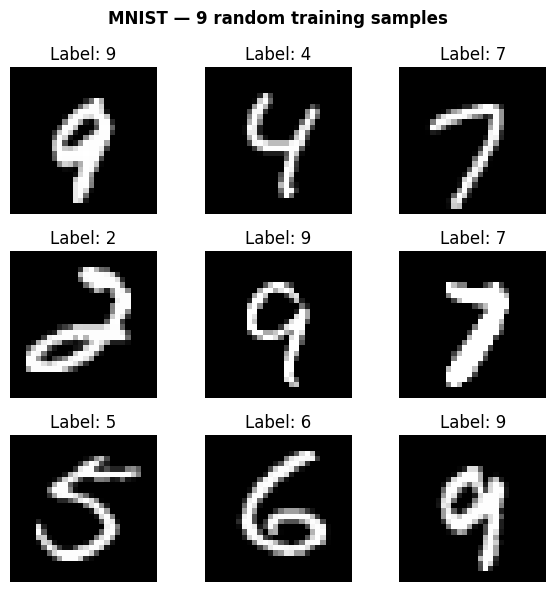

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transforms: tensor + normalize (MNIST mean/std commonly used)
mnist_transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.1307,), (0.3081,)),
])

data_dir = os.path.join(os.getcwd(), "data")
train_ds = torchvision.datasets.MNIST(root=data_dir, train=True, download=True, transform=mnist_transform)
test_ds = torchvision.datasets.MNIST(root=data_dir, train=False, download=True, transform=mnist_transform)

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=(device.type == "cuda"))
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=(device.type == "cuda"))

print(f"Train samples: {len(train_ds)} | Test samples: {len(test_ds)}")

# Visualize 9 random training images (unnormalize for display)
fig, axes = plt.subplots(3, 3, figsize=(6, 6))
axes = axes.ravel()
indices = random.sample(range(len(train_ds)), 9)
mean, std = 0.1307, 0.3081
for ax, idx in zip(axes, indices):
    img, label = train_ds[idx]
    img_np = img.squeeze().numpy() * std + mean
    ax.imshow(img_np, cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")
plt.suptitle("MNIST — 9 random training samples", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


<a id="32"></a>
### 3.2 Define a Simple CNN Architecture (≈10 min)

**Architecture sketch:** three **Conv → ReLU → MaxPool** blocks extract hierarchical features; **fully connected** layers map features to 10 digit classes.

| Layer | Role |
|--------|------|
| `Conv2d` | Local feature detectors (edges, strokes) |
| `ReLU` | Nonlinearity |
| `MaxPool2d` | Spatial downsampling + translation robustness |
| `Linear` | Class scores |


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SimpleCNN(nn.Module):
    """Small CNN for 28x28 MNIST (1 input channel)."""

    def __init__(self, num_classes: int = 10):
        super().__init__()
        # Block 1: 1 -> 32 channels
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2)  # 28 -> 14

        # Block 2: 32 -> 64
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2)  # 14 -> 7

        # Block 3: 64 -> 128
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(2)  # 7 -> 3 (floor)

        # After pool3: 128 x 3 x 3 = 1152
        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


model = SimpleCNN(num_classes=10).to(device)
print(model)
# Sanity check tensor shape
dummy = torch.zeros(2, 1, 28, 28, device=device)
print("Output shape:", model(dummy).shape)


SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1152, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)
Output shape: torch.Size([2, 10])


<a id="33"></a>
### 3.3 Training Setup (≈5 min)

We use **cross-entropy** (multi-class classification) and **Adam** with learning rate **0.001**. Hyperparameters: **batch size 64**, **5 epochs** (enough for a strong baseline on MNIST).


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LR = 1e-3
EPOCHS = 5
WEIGHT_DECAY = 0.0  # tutorial baseline; Part 2 explores L2 regularization

model = SimpleCNN(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

print(f"Loss: CrossEntropyLoss | Optimizer: Adam(lr={LR}, weight_decay={WEIGHT_DECAY})")
print(f"Epochs: {EPOCHS} | Batch size: {BATCH_SIZE} | Device: {device}")


Loss: CrossEntropyLoss | Optimizer: Adam(lr=0.001, weight_decay=0.0)
Epochs: 5 | Batch size: 64 | Device: cuda


<a id="34"></a>
### 3.4 Training Loop + Live Plot (≈12 min)

Each epoch we compute **training loss/accuracy** and **test loss/accuracy**. The plot **refreshes every epoch** so you can watch learning progress. `%%time` reports wall-clock time for the whole training block.


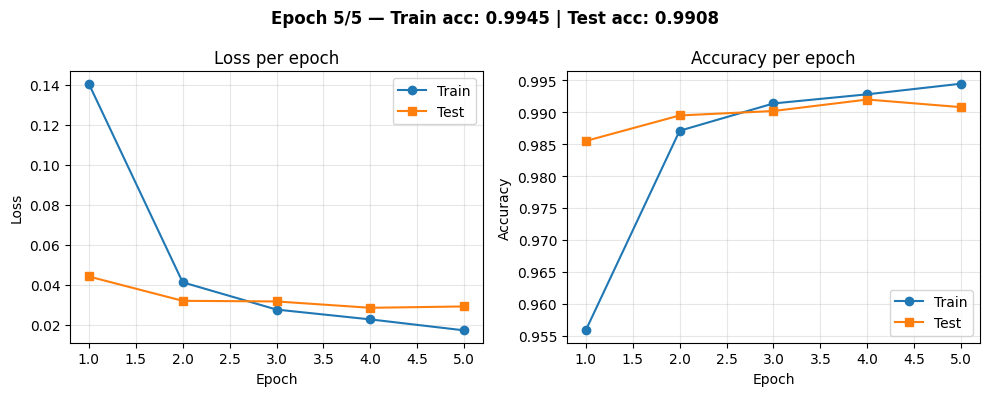

Final — Train acc: 0.9944833333333334 Test acc: 0.9908
CPU times: user 1min 42s, sys: 422 ms, total: 1min 42s
Wall time: 1min 44s


In [5]:
%%time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(42)

model = SimpleCNN(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)


def run_epoch(model, loader, train: bool):
    if train:
        model.train()
    else:
        model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            if train:
                optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * xb.size(0)
            pred = logits.argmax(dim=1)
            correct += (pred == yb).sum().item()
            total += yb.size(0)
    return total_loss / total, correct / total


history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(model, train_loader, train=True)
    te_loss, te_acc = run_epoch(model, test_loader, train=False)
    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["test_loss"].append(te_loss)
    history["test_acc"].append(te_acc)

    clear_output(wait=True)
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    epochs_x = range(1, len(history["train_loss"]) + 1)
    ax[0].plot(epochs_x, history["train_loss"], "o-", label="Train")
    ax[0].plot(epochs_x, history["test_loss"], "s-", label="Test")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].set_title("Loss per epoch")
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)

    ax[1].plot(epochs_x, history["train_acc"], "o-", label="Train")
    ax[1].plot(epochs_x, history["test_acc"], "s-", label="Test")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Accuracy")
    ax[1].set_title("Accuracy per epoch")
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)
    plt.suptitle(f"Epoch {epoch}/{EPOCHS} — Train acc: {tr_acc:.4f} | Test acc: {te_acc:.4f}", fontweight="bold")
    plt.tight_layout()
    plt.show()

print("Final — Train acc:", history["train_acc"][-1], "Test acc:", history["test_acc"][-1])


<a id="35"></a>
### 3.5 Final Evaluation & Confusion Matrix (≈5 min)

A **confusion matrix** shows which digits are confused with which—useful for error analysis before moving to harder datasets or generative evaluation.


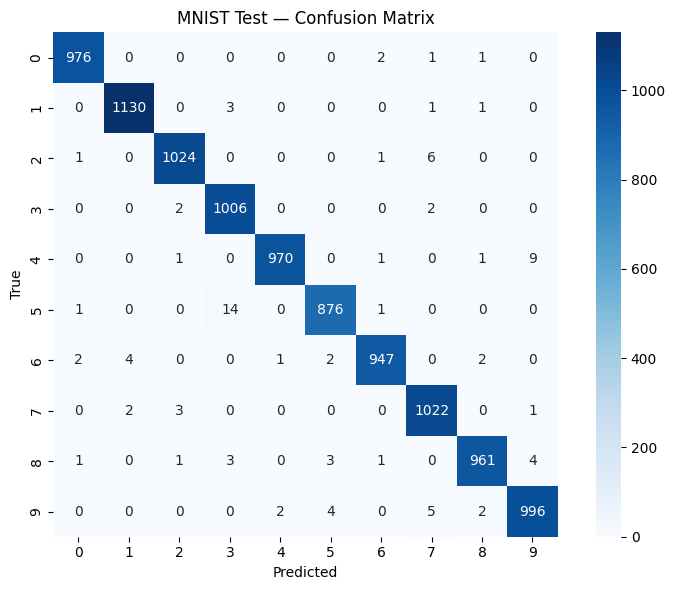

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

@torch.no_grad()
def collect_predictions(model, loader):
    model.eval()
    ys, yhats = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb)
        pred = logits.argmax(dim=1).cpu().numpy()
        ys.append(yb.numpy())
        yhats.append(pred)
    return np.concatenate(ys), np.concatenate(yhats)


y_true, y_pred = collect_predictions(model, test_loader)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", square=True)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("MNIST Test — Confusion Matrix")
plt.tight_layout()
plt.show()


<a id="36"></a>
### 3.6 Quick Hyperparameter Experiment (≈5 min)

Compare **two learning rates** (e.g. **0.01** vs **0.001**) with the same seed and epochs. **Expectation:** too large a learning rate may oscillate or underperform; too small may learn slowly.


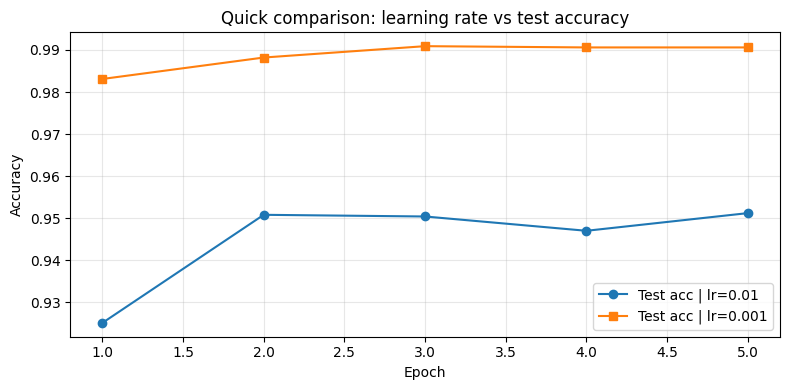

Final test acc (lr=0.01): 0.9512
Final test acc (lr=0.001): 0.9906
CPU times: user 3min 15s, sys: 547 ms, total: 3min 15s
Wall time: 3min 22s


In [7]:
%%time
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def train_mnist_cnn(lr: float, epochs: int = 5, seed: int = 123):
    """Self-contained train loop (does not rely on run_epoch from §3.4)."""
    set_seed(seed)
    m = SimpleCNN(10).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    hist = {"train_loss": [], "test_acc": []}
    for _ in range(epochs):
        m.train()
        running_loss, n = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(set_to_none=True)
            loss = crit(m(xb), yb)
            loss.backward()
            opt.step()
            running_loss += loss.item() * xb.size(0)
            n += xb.size(0)
        tr_loss = running_loss / max(n, 1)
        m.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = m(xb).argmax(dim=1)
                correct += (pred == yb).sum().item()
                total += yb.size(0)
        te_acc = correct / max(total, 1)
        hist["train_loss"].append(tr_loss)
        hist["test_acc"].append(te_acc)
    return m, hist


lr_a, lr_b = 0.01, 0.001
_, h_high = train_mnist_cnn(lr_a, epochs=5, seed=123)
_, h_low = train_mnist_cnn(lr_b, epochs=5, seed=123)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 6), h_high["test_acc"], "o-", label=f"Test acc | lr={lr_a}")
plt.plot(range(1, 6), h_low["test_acc"], "s-", label=f"Test acc | lr={lr_b}")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Quick comparison: learning rate vs test accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Final test acc (lr={lr_a}): {h_high['test_acc'][-1]:.4f}")
print(f"Final test acc (lr={lr_b}): {h_low['test_acc'][-1]:.4f}")


<a id="part2"></a>
## Part 2: Hands-On Student Tasks (≈85–95 minutes)

**Instructions:** Complete the tasks below in order. Use tables/plots where asked. Keep **batch size**, **epochs**, and **seeds** **documented** in your write-up so results are comparable. **Do not copy full solutions from the web**—implement your own code in the cells provided.

> **Tip:** Copy helper functions (`run_epoch`, model classes) from Part 1 into your solution cells or refactor into a single code cell at the top of Part 2.

When a task asks for **analysis**, **tables**, or **figures**, add **Markdown cells** below your code and paste plots or type your answers there.

<a id="grading"></a>
### Grading rubric (100 points total)

| Task | Topic | Points |
|------|--------|--------:|
| **Task 1** | Hyperparameter tuning (≥3 configs, plot + analysis) | **20** |
| **Task 2** | Dropout regularization (train vs test, discussion) | **20** |
| **Task 3** | L2 / weight decay (curves + interpretation) | **20** |
| **Task 4** | Data augmentation (baseline comparison) | **20** |
| **Task 5** | Deeper CNN architecture (comparison vs `SimpleCNN`) | **20** |
| | **Total** | **100** |

*Optional **Bonus** task below is **not** part of the 100 points; instructors may award **extra credit** separately.*


### Task 1 (≈15 min): Hyperparameter Tuning — **20 / 100 points**

**Goal:** Run **at least three** distinct configurations combining **learning rates** and/or **optimizers** and/or **batch sizes**. Plot **final test accuracy** (bar chart or table + plot) and briefly comment on which worked best.

**Deliverable:** A comparison plot and 2–4 sentences of analysis.

**Hints:**
- Vary **one or two** factors at a time so interpretations stay clear (e.g. three LRs with fixed batch, or three batch sizes with fixed LR).
- When **batch size** changes, rebuild `DataLoader(..., batch_size=...)`.
- `torch.optim.SGD(model.parameters(), lr=..., momentum=0.9)` often needs a different LR than **Adam**.
- Use the **same** `EPOCHS` and **seed** across configs for a fair comparison.



Running: SGD lr=0.01
Accuracy: 0.9801

Running: SGD lr=0.1
Accuracy: 0.9806

Running: Adam lr=0.001
Accuracy: 0.9814

Final Results:
SGD lr=0.01 → 0.9801
SGD lr=0.1 → 0.9806
Adam lr=0.001 → 0.9814


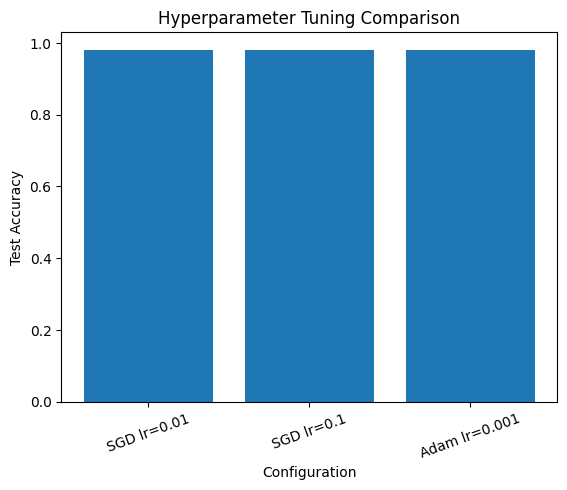

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
# Task 1 — TODO: implement in this cell (see hints in the markdown above).
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(42)

EPOCHS = 5
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Linear(16*14*14, 10)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

transform = transforms.ToTensor()
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST('./data', train=False, download=True, transform=transform)

configs = [
    {"name": "SGD lr=0.01", "batch_size": 64, "optimizer": "SGD", "lr": 0.01},
    {"name": "SGD lr=0.1", "batch_size": 64, "optimizer": "SGD", "lr": 0.1},
    {"name": "Adam lr=0.001", "batch_size": 64, "optimizer": "Adam", "lr": 0.001}
]

results = []

def train(model, loader, optimizer, criterion):
    model.train()
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            _, pred = torch.max(out, 1)
            total += y.size(0)
            correct += (pred == y).sum().item()
    return correct / total

for config in configs:
    print(f"\nRunning: {config['name']}")
    set_seed(42)

    train_loader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

    model = SimpleCNN().to(device)

    if config["optimizer"] == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=config["lr"], momentum=0.9)
    else:
        optimizer = optim.Adam(model.parameters(), lr=config["lr"])

    criterion = nn.CrossEntropyLoss()

    for epoch in range(EPOCHS):
        train(model, train_loader, optimizer, criterion)

    acc = evaluate(model, test_loader)
    print(f"Accuracy: {acc:.4f}")

    results.append(acc)

print("\nFinal Results:")
for i, config in enumerate(configs):
    print(f"{config['name']} → {results[i]:.4f}")

plt.figure()
plt.bar([c["name"] for c in configs], results)
plt.xlabel("Configuration")
plt.ylabel("Test Accuracy")
plt.title("Hyperparameter Tuning Comparison")
plt.xticks(rotation=20)
plt.show()

### Task 2 (≈20 min): Add Dropout Regularization — **20 / 100 points**

**Goal:** Insert **`nn.Dropout(p)`** after activation in each conv block and **before** fully-connected layers (try **p = 0.25** and **0.5**). Retrain with the same hyperparameters as the tutorial baseline. Compare **train vs test curves** to discuss **overfitting**.

**Deliverable:** Plot loss/accuracy for baseline vs dropout model(s) + short explanation.

**Hints:**
- Subclass `nn.Module` or duplicate **`SimpleCNN`** from Part 1 and add `nn.Dropout` layers.
- **`model.train()`** enables dropout; **`model.eval()`** disables it—use `eval()` when measuring test accuracy.
- You may see **higher train loss** with dropout but **closer train–test gap** (less overfitting).


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.72MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.3MB/s]



Training: Baseline

Training: Dropout p=0.25

Training: Dropout p=0.5


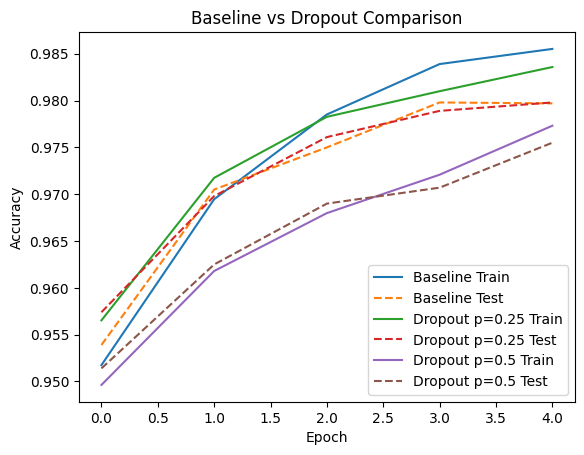

In [3]:
# Task 2 — TODO: implement a dropout-equipped CNN and training comparison here.
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import random
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed(42)
EPOCHS = 5
LR = 0.001
BATCH_SIZE = 64
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Linear(16*14*14, 10)
    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

class CNNWithDropout(nn.Module):
    def __init__(self, p=0.5):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.Dropout(p),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Dropout(p),
            nn.Linear(16*14*14, 10)
        )
    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

transform = transforms.ToTensor()
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=1000, shuffle=False)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            _, pred = torch.max(out, 1)
            total += y.size(0)
            correct += (pred == y).sum().item()
    return correct / total

models = {
    "Baseline": SimpleCNN().to(device),
    "Dropout p=0.25": CNNWithDropout(p=0.25).to(device),
    "Dropout p=0.5": CNNWithDropout(p=0.5).to(device)
}

results = {}

for name, model in models.items():
    print(f"\nTraining: {name}")

    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    train_accs = []
    test_accs = []

    for epoch in range(EPOCHS):
        train_epoch(model, train_loader, optimizer, criterion)

        train_acc = evaluate(model, train_loader)
        test_acc = evaluate(model, test_loader)

        train_accs.append(train_acc)
        test_accs.append(test_acc)

    results[name] = (train_accs, test_accs)

plt.figure()

for name, (train_accs, test_accs) in results.items():
    plt.plot(train_accs, label=f"{name} Train")
    plt.plot(test_accs, linestyle="--", label=f"{name} Test")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline vs Dropout Comparison")
plt.legend()
plt.show()

### Task 3 (≈15 min): L2 Regularization (Weight Decay) — **20 / 100 points**

**Goal:** Add **`weight_decay`** (e.g. **1e-4** or **5e-4**) to **Adam** (or SGD). Compare **training and test loss curves** against **weight_decay = 0**.

**Deliverable:** Overlayed loss curves + 2–3 sentences on whether test loss improved.

**Hints:**
- Pass `weight_decay=...` into **`torch.optim.Adam`** (or SGD)—see [PyTorch Adam docs](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html).
- Run the **same** number of epochs for each setting; overlay **train** and **test** loss on one figure (different line styles/colors).
- If curves are noisy, fix the seed or average over a short window—focus on **trend**.


Training with weight_decay=0.0
Training with weight_decay=0.0001
Training with weight_decay=0.0005


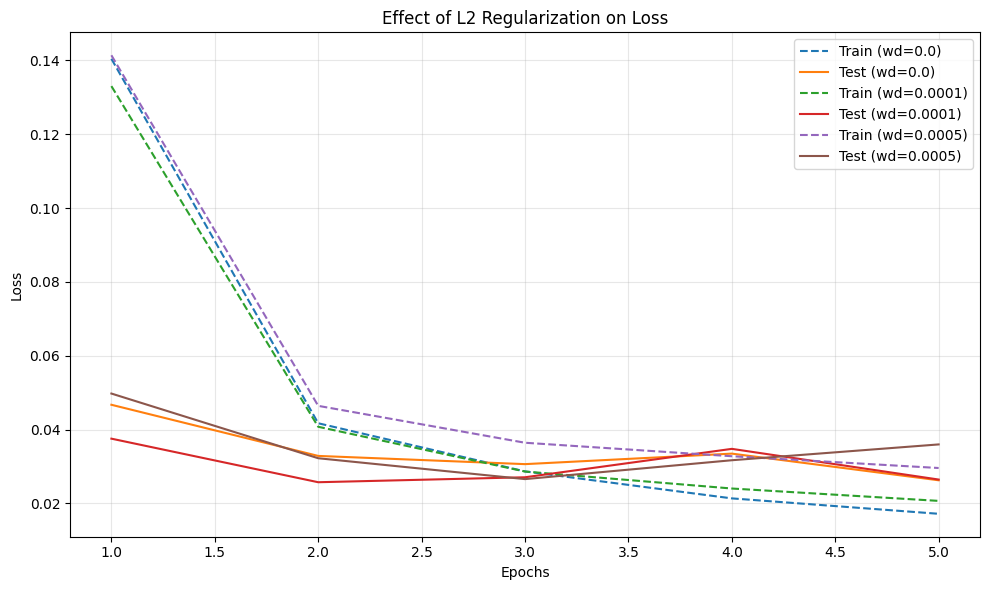

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import random
import numpy as np
import os
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
EPOCHS = 5
BATCH_SIZE = 64
LR =

class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x
mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

data_dir = os.path.join(os.getcwd(), "data")

train_ds = datasets.MNIST(root=data_dir, train=True, download=True, transform=mnist_transform)
test_ds = datasets.MNIST(root=data_dir, train=False, download=True, transform=mnist_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=(device.type == "cuda"))
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=(device.type == "cuda"))

def run_epoch(model, loader, criterion, optimizer=None, train: bool = True):
    if train:
        model.train()
    else:
        model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            if train:
                optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * xb.size(0)
            pred = logits.argmax(dim=1)
            correct += (pred == yb).sum().item()
            total += yb.size(0)
    return total_loss / total, correct / total


weight_decays = [0.0, 1e-4, 5e-4]
epochs = 5
results = {}

for wd in weight_decays:
    print(f"Training with weight_decay={wd}")
    model = SimpleCNN(num_classes=10).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=wd)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, train=True)
        train_losses.append(tr_loss)
        te_loss, te_acc = run_epoch(model, test_loader, criterion, train=False)
        test_losses.append(te_loss)

    results[wd] = {'train': train_losses, 'test': test_losses}

plt.figure(figsize=(10, 6))
for wd, losses in results.items():
    plt.plot(range(1, epochs + 1), losses['train'], label=f'Train (wd={wd})', linestyle='--')
    plt.plot(range(1, epochs + 1), losses['test'], label=f'Test (wd={wd})', linestyle='-')

plt.title('Effect of L2 Regularization on Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Task 4 (≈20 min): Data Augmentation — **20 / 100 points**

**Goal:** Build a **training** `transform` with **`RandomHorizontalFlip`**, **`RandomRotation`** (e.g. degrees=10), plus `ToTensor` and `Normalize`. Keep **test** transform unchanged. Retrain and report **test accuracy** vs the non-augmented baseline.

**Note:** MNIST digits are nearly centered; augmentation is **mild**. The point is to practice **`transforms`**—on harder datasets, augmentation matters more.

**Deliverable:** Before/after test accuracy + one sentence on improvement or trade-offs.

**Hints:**
- Apply **PIL**-compatible transforms **before** `ToTensor()`; **normalize** after `ToTensor()` using the usual MNIST mean/std from Part 1.
- `torchvision.datasets.MNIST(..., transform=train_transform)` for train; separate `test_transform` for test.
- Compare fairly: same **epochs**, **LR**, **architecture**, **seed** as baseline—only the **train** transform changes.


Training Baseline Model
Baseline Final Test Acc: 0.9874

Training Augmented Model...
Augmented Final Test Acc: 0.9863


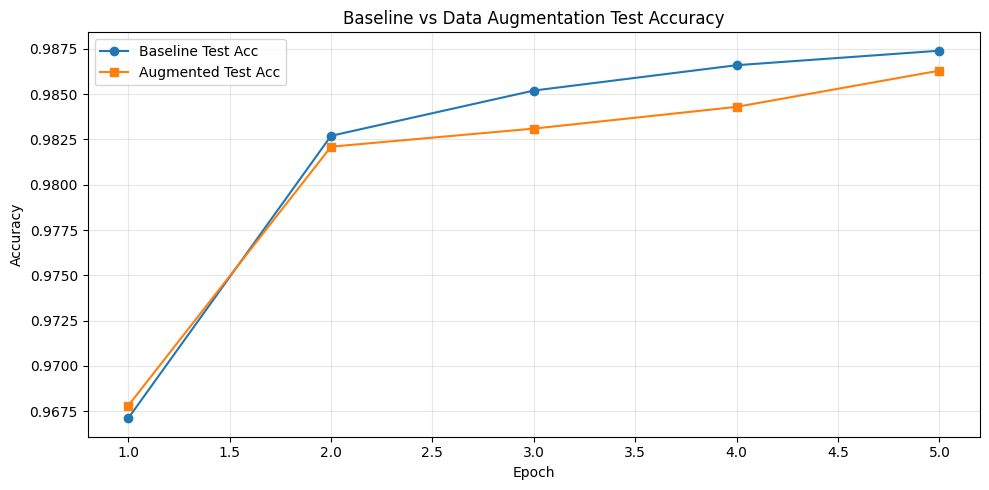


Before augmentation test accuracy: 0.9874
After augmentation test accuracy: 0.9863


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import random
import numpy as np
import matplotlib.pyplot as plt
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
EPOCHS = 5
LR = 0.001
BATCH_SIZE = 64

class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2)  # 28 -> 14

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2)  # 14 -> 7

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(2)  # 7 -> 3 (floor)

        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

def run_epoch(model, loader, criterion, optimizer=None, train: bool = True):
    if train:
        model.train()
    else:
        model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            if train:
                optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * xb.size(0)
            pred = logits.argmax(dim=1)
            correct += (pred == yb).sum().item()
            total += yb.size(0)
    return total_loss / total, correct / total

print("Training Baseline Model")
set_seed(42)
model_baseline = SimpleCNN(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer_baseline = torch.optim.Adam(model_baseline.parameters(), lr=LR)

history_baseline = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(model_baseline, train_loader, criterion, optimizer_baseline, train=True)
    te_loss, te_acc = run_epoch(model_baseline, test_loader, criterion, train=False)
    history_baseline["train_loss"].append(tr_loss)
    history_baseline["train_acc"].append(tr_acc)
    history_baseline["test_loss"].append(te_loss)
    history_baseline["test_acc"].append(te_acc)

print(f"Baseline Final Test Acc: {history_baseline['test_acc'][-1]:.4f}")
print("\nTraining Augmented Model...")
train_transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
data_dir = os.path.join(os.getcwd(), "data")
train_dataset_aug = datasets.MNIST(root=data_dir, train=True, download=True, transform=train_transform_aug)
test_dataset_aug = datasets.MNIST(root=data_dir, train=False, download=True, transform=test_transform)

train_loader_aug = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=(device.type == "cuda"))
test_loader_aug = DataLoader(test_dataset_aug, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=(device.type == "cuda"))

set_seed(42)
model_aug = SimpleCNN(num_classes=10).to(device)
optimizer_aug = torch.optim.Adam(model_aug.parameters(), lr=LR)

history_aug = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(model_aug, train_loader_aug, criterion, optimizer_aug, train=True)
    te_loss, te_acc = run_epoch(model_aug, test_loader_aug, criterion, train=False)
    history_aug["train_loss"].append(tr_loss)
    history_aug["train_acc"].append(tr_acc)
    history_aug["test_loss"].append(te_loss)
    history_aug["test_acc"].append(te_acc)

print(f"Augmented Final Test Acc: {history_aug['test_acc'][-1]:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS + 1), history_baseline['test_acc'], 'o-', label='Baseline Test Acc')
plt.plot(range(1, EPOCHS + 1), history_aug['test_acc'], 's-', label='Augmented Test Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Baseline vs Data Augmentation Test Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nBefore augmentation test accuracy: {history_baseline['test_acc'][-1]:.4f}")
print(f"After augmentation test accuracy: {history_aug['test_acc'][-1]:.4f}")

<a id="task5"></a>
### Task 5 (≈20 min): Deeper architecture — more convolutional layers — **20 / 100 points**

**Goal:** Extend the **Part 1** `SimpleCNN` by adding **more conv layers** (e.g. **two convolutions per block** before each pool, VGG-style, or an extra block with compatible downsampling). Train with the **same** hyperparameters (epochs, batch size, LR) as the tutorial when possible and compare **test accuracy**, **parameter count**, and **training time** vs `SimpleCNN`.

**Why it matters:** Deeper stacks can learn richer features but may **overfit** small datasets or need **more regularization**—a core trade-off in both **classification** and **generative** CNN backbones.

**Deliverable:** Table or short paragraph comparing baseline vs deeper model + one plot (e.g. test accuracy vs epoch). If the deeper net underperforms, briefly hypothesize why (overfitting, optimization, capacity vs data).

**Hints:**
- Trace tensor shape after **each** conv and pool: MNIST with three `MaxPool2d(2)` typically ends near **3×3** feature maps if you match Part 1’s padding/kernel choices.
- **`nn.Linear` in_features** must equal `channels * height * width` after `flatten`—use a dummy input `torch.zeros(1, 1, 28, 28, device=device)` to verify.
- Count parameters: `sum(p.numel() for p in model.parameters())`.
- Optional: use `%%time` once per training run to compare wall time.


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class DeeperCNN(nn.Module):
    def __init__(self):
        super(DeeperCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool1(x)

        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool2(x)

        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

model = DeeperCNN().to(device)
dummy_input = torch.zeros(1, 1, 28, 28).to(device)
output = model(dummy_input)
print(f"Output shape: {output.shape}") # Should be [1, 10]

# TODO:
# 1) Define a new nn.Module with MORE conv layers than SimpleCNN (e.g. two convs per block before each pool).
# 2) Ensure fc layer input size matches your feature map — verify with a dummy tensor.
# 3) Train vs SimpleCNN with same EPOCHS, LR, batch_size; compare test accuracy, param count, and (optional) wall time.

pass  # TODO: remove `pass` and implement Task 5.

Output shape: torch.Size([1, 10])


### Bonus Task (optional): Harder Dataset — *extra credit only (not part of 100 points)*

**Goal:** Swap **MNIST** for **Fashion-MNIST** (`torchvision.datasets.FashionMNIST`) or a **small CIFAR-10** run (e.g. **subset** of 5000 train images for speed). Reuse the same **SimpleCNN** idea—you may need **3 input channels** and different **architecture/normalization** for CIFAR-10.

**Hints:**
- **Fashion-MNIST:** same spatial size and channels as MNIST; adjust **normalization** (look up common mean/std or compute from a batch).
- **CIFAR-10:** `nn.Conv2d(3, ...)`; images are **32×32**—either adapt pooling/FC sizes or use a reference architecture from tutorials.
- Use `torch.utils.data.Subset` if you need a **small** training set for fast iteration.


In [ ]:
# Bonus — TODO (optional): experiment with Fashion-MNIST or CIFAR-10 subset.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# TODO: Load dataset(s), build transforms & DataLoaders, adapt model if needed, train, report test accuracy.
# See hints in the markdown above.

pass  # TODO: remove `pass` if you attempt the bonus.


<a id="summary"></a>
## Lab Summary & Takeaways

- **CNNs** stack **convolutions**, **nonlinearities**, and **pooling** to learn **hierarchical visual features** from raw pixels.
- **Training** requires careful choice of **learning rate**, **batch size**, and **optimizer**—these interact and should be validated on a **held-out test** set.
- **Regularization** (**dropout**, **weight decay**) and **data augmentation** reduce **overfitting** and often improve **generalization**.
- **Monitoring** **loss** and **accuracy** curves, plus a **confusion matrix**, makes debugging and comparison systematic.
- **Depth** and **width** increase model **capacity**; match them to **data size** and **regularization**, or you may see **overfitting** or slower optimization.

### Next Steps for Generative AI

The same **convolutional** ideas appear throughout generative modeling:

- **GANs:** convolutional **generator** and **discriminator** (e.g., DCGAN).
- **Diffusion models:** **U-Net**-style CNNs predict noise or score functions (e.g., models behind **Stable Diffusion** use CNN backbones + attention).
- **Autoencoders / VAEs:** CNN **encoders** and **decoders** map images to latent spaces and back.

Mastering **classification CNNs** is a direct stepping stone to reading and modifying these architectures.


<a id="refs"></a>
## References & Further Reading

- [PyTorch Tutorials — Training a Classifier](https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html)
- [torchvision.datasets](https://pytorch.org/vision/stable/datasets.html)
- [LeCun et al., Gradient-based learning applied to document recognition (1998)](http://yann.lecun.com/exdb/publis/pdf/lecun-01a.pdf) — classic CNN / MNIST.
- [Krizhevsky et al., ImageNet Classification with Deep CNNs (AlexNet, 2012)](https://papers.nips.cc/paper/4824-imagenet-classification-with-deep-convolutional-neural-networks.pdf)
